# RoboterProgrammierung Projektaufgabe — Roundtrip-Path 

## Aufgabe b) Benchmarking

Evaluieren mit BasicPRM, LazyPRM, VisibilityPRM anhand von:
- 2x 2-DoF Punktroboter
- 2x 3-DoF ShapeRoboter
- (TODO: 2x Planarroboter)

In [1]:
import sys
sys.path.append(".")
sys.path.append("./collisionChecker")

import matplotlib.pyplot as plt
import time
import importlib
%matplotlib inline

from shapely.geometry import Point, LineString
from shapely import plotting

# Benchmark Suite importieren (mit Reload falls schon geladen)
import IPTestSuiteBenchmark
importlib.reload(IPTestSuiteBenchmark)
from IPTestSuiteBenchmark import benchList, getBenchmarks2DoF, getBenchmarks3DoF, printBenchmarkOverview

# Planer importieren
from IPLazyPRM import LazyPRM
from IPBasicPRM import BasicPRM
from IPVisibilityPRM import VisPRM
from IPVisibilityPRMRound import VisPRMRound
from IPRoundtripPlanner import RoundtripPlanner

#Animator importieren
from PathAnimator import PathAnimator

# Übersicht
printBenchmarkOverview()
print(f"\nAnzahl Benchmarks geladen: {len(benchList)}")
for i, b in enumerate(benchList):
    print(f"  {i+1}. {b.name}")

BENCHMARK ÜBERSICHT
1. doubleBowl_2DoF (2-DoF, Level 1)
   Start: [11, 9]
   Goals: [[17, 17], [3, 3], [25, 5], [15, 27]]
2. arcade_2DoF (2-DoF, Level 2)
   Start: [25, 5]
   Goals: [[5, 20], [25, 27], [5, 10], [10, 5]]
3. spinner_3DoF (3-DoF, Level 2)
   Start: [15, 5, 0]
   Goals: [[5, 15, 270], [15, 25, 180], [25, 15, 90]]
4. grid_3DoF (3-DoF, Level 3)
   Start: [2.5, 2.5, 0]
   Goals: [[27, 7, 180], [17, 28, 90], [7, 17, 270]]

Anzahl Benchmarks geladen: 4
  1. doubleBowl_2DoF
  2. arcade_2DoF
  3. spinner_3DoF
  4. grid_3DoF


In [2]:
PLANNERS = {
    "LazyPRM": {
        "config": {
            "initialRoadmapSize": 40,
            "updateRoadmapSize": 20,
            "kNearest": 5,
            "maxIterations": 40
        },
        "class": LazyPRM
    },
    "BasicPRM": {
        "config": {
            "radius": 5.0,             # Suchradius für Nachbarn
            "numNodes": 300,           # Anzahl der zu generierenden Knoten
            "useKDTree": True          # KDTree für schnelle Nachbarsuche (optional)
        },
        "class": BasicPRM
    },
    "VisPRM": {
        "config": {
            "ntry": 40                 # Anzahl Versuche für Roadmap-Erstellung
        },
        "class": VisPRM,
    },
    "VisPRMRound": {
        "config": {
            "ntry": 1000                 # Roundtrip-Variante nutzt eigene TSP-Logik
        },
        "class": VisPRMRound
    },
}

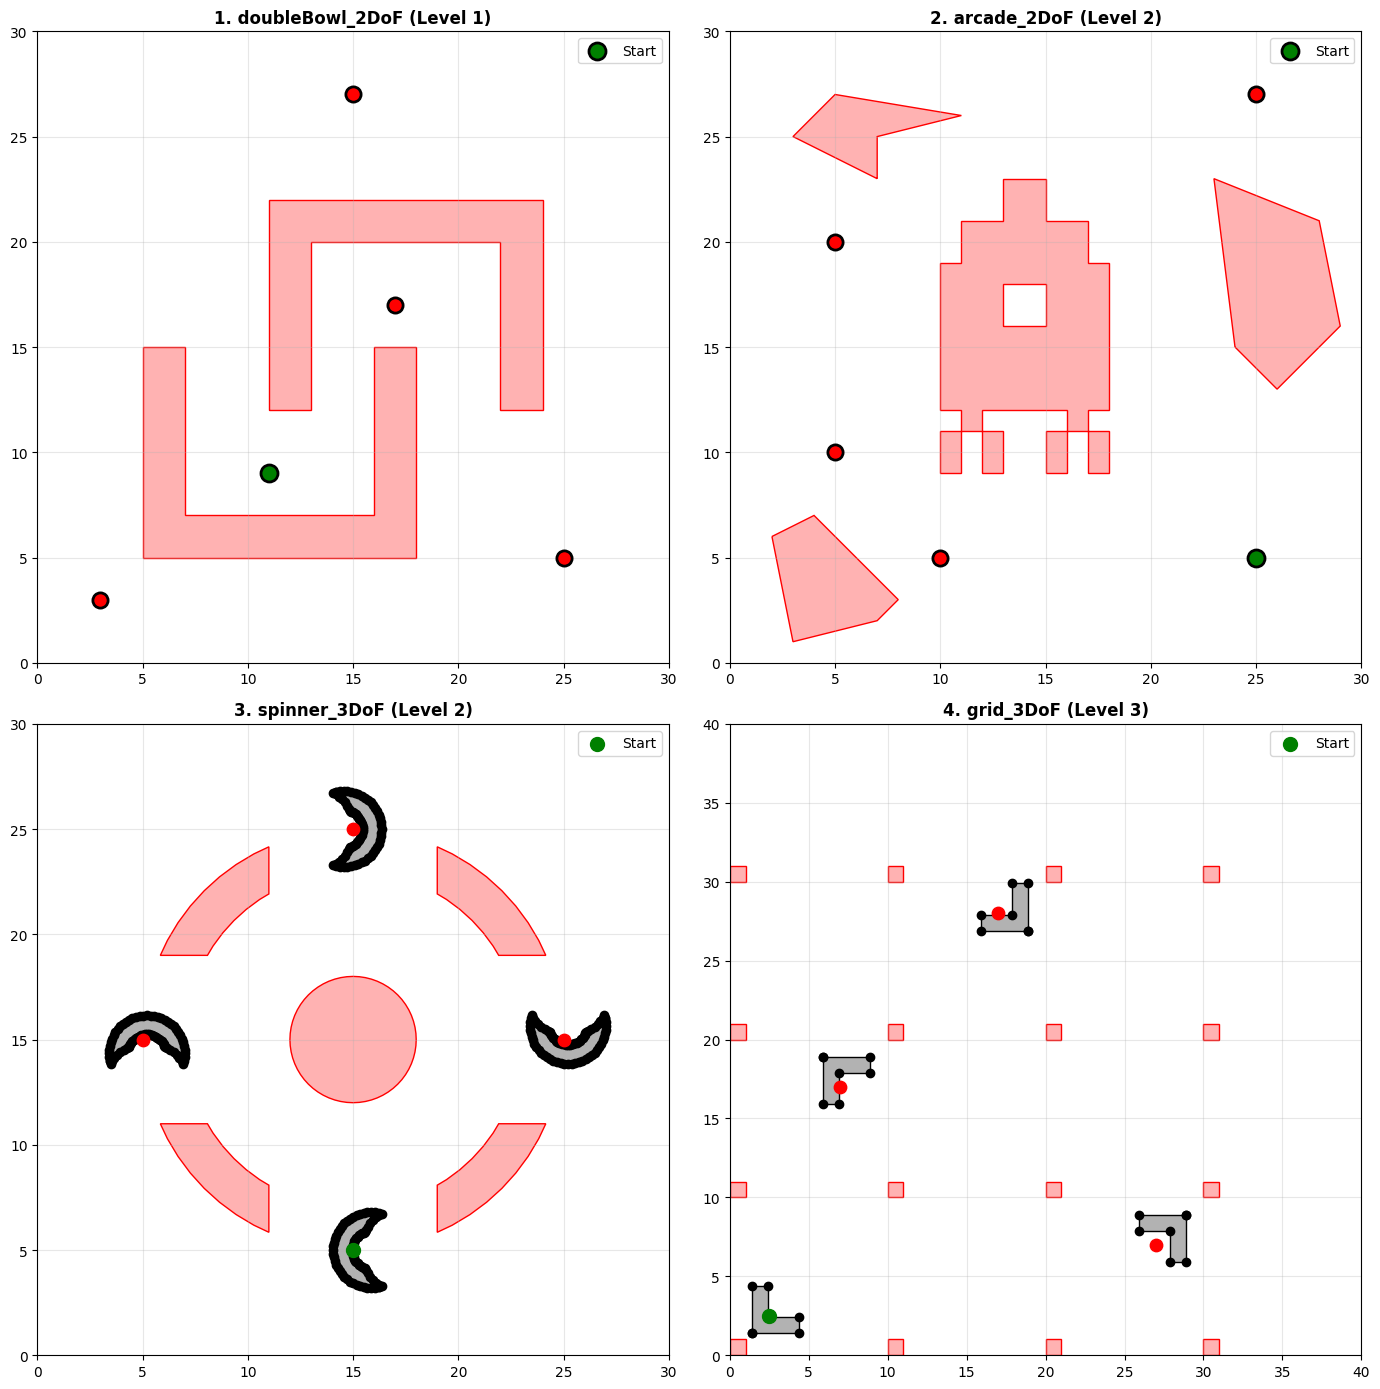

In [3]:
# ============================================================================
# ALLE BENCHMARK-SZENEN VISUALISIEREN
# ============================================================================

n_benchmarks = len(benchList)
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()

for idx in range(n_benchmarks):
    benchmark = benchList[idx]
    ax = axes[idx]

    # Jeden Plot komplett zurücksetzen
    ax.clear()

    # Limits vom jeweiligen CollisionChecker
    limits = benchmark.collisionChecker.getEnvironmentLimits()
    ax.set_xlim(limits[0])
    ax.set_ylim(limits[1])
    ax.grid(True, alpha=0.3)

    # Hindernisse des jeweiligen Benchmarks zeichnen
    benchmark.collisionChecker.drawObstacles(ax)

    # Start und Ziele
    start_pos = benchmark.startList[0]
    goals = benchmark.goalList

    # Prüfen ob 3DoF (hat drawRobot Methode)
    is_3dof = hasattr(benchmark.collisionChecker, 'drawRobot')

    if is_3dof:
        # 3DoF: Roboter zeichnen
        benchmark.collisionChecker.drawRobot(ax, start_pos)
        for goal in goals:
            benchmark.collisionChecker.drawRobot(ax, goal)
        ax.scatter(start_pos[0], start_pos[1], color='green', s=100, zorder=10, marker='o', label='Start')
        for i, goal in enumerate(goals, 1):
            ax.scatter(goal[0], goal[1], color='red', s=80, zorder=10, marker='o')
    else:
        # 2DoF: Nur Punkte
        ax.scatter(start_pos[0], start_pos[1], color='green', s=150, zorder=10, marker='o', edgecolors='black', linewidths=2, label='Start')
        for i, goal in enumerate(goals, 1):
            ax.scatter(goal[0], goal[1], color='red', s=120, zorder=10, marker='o', edgecolors='black', linewidths=2)

    ax.set_title(f"{idx+1}. {benchmark.name} (Level {benchmark.level})", fontweight='bold', fontsize=12)
    ax.set_aspect('equal')
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================================
# BENCHMARKING: Alle 2DoF Benchmarks mit allen Planern
# ============================================================================
benchmarks_2dof = getBenchmarks2DoF()
planner_names = list(PLANNERS.keys())

results = []

print("=" * 70)
print("ROUNDTRIP BENCHMARK - 2DoF Szenen")
print("=" * 70)

for bench in benchmarks_2dof:
    print(f"\n Benchmark: {bench.name}")
    print("-" * 50)

    env = bench.collisionChecker
    start_pos = bench.startList[0]
    goal_list = bench.goalList

    for planner_name in planner_names:
        try:
            # Planer initialisieren
            planner_class = PLANNERS[planner_name]["class"]
            planner_config = PLANNERS[planner_name]["config"]
            base_planner = planner_class(env)

            # VisPRMRound bringt die Roundtrip-Logik selbst mit, andere nutzen RoundtripPlanner
            start_time = time.time()
            if planner_name == "VisPRMRound":
                path = base_planner.planPath(start_pos, goal_list, planner_config)
            else:
                roundtrip = RoundtripPlanner(env, base_planner)
                path = roundtrip.planPath([start_pos], goal_list, planner_config)
            end_time = time.time()

            planning_time = end_time - start_time
            path_length = len(path)

            # Ergebnis speichern
            results.append({
                "benchmark": bench.name,
                "planner": planner_name,
                "time": planning_time,
                "path_points": path_length,
                "path": path,
                "success": True
            })

            print(f"  {planner_name}: {planning_time:.3f}s, {path_length} Punkte")

        except Exception as e:
            results.append({
                "benchmark": bench.name,
                "planner": planner_name,
                "time": None,
                "path_points": None,
                "path": None,
                "success": False
            })
            print(f"  {planner_name}: Fehler - {str(e)[:50]}...")

print("\n" + "=" * 70)

ROUNDTRIP BENCHMARK - 2DoF Szenen

 Benchmark: doubleBowl_2DoF
--------------------------------------------------
Path Planing gestartet mit LazyPRM

Start: [11, 9]
Goals: 4 Ziele
  - Goal 1: [17, 17]
  - Goal 2: [3, 3]
  - Goal 3: [25, 5]
  - Goal 4: [15, 27]
  TSP-Lösung (Christofides): Approximierte Distanz = 75.15
  Optimierte Reihenfolge: Start → [3, 3] → [25, 5] → [17, 17] → [15, 27] → Start

→ Plane Segment 1/5: [11, 9] → [3, 3]
Pfad gefunden: 8 Punkte (im Versuch 1)
Konvertiert zu Koordinaten: 8 Punkte

→ Plane Segment 2/5: [3, 3] → [25, 5]
Pfad gefunden: 13 Punkte (im Versuch 1)
Konvertiert zu Koordinaten: 13 Punkte

→ Plane Segment 3/5: [25, 5] → [17, 17]
Pfad gefunden: 5 Punkte (im Versuch 1)
Konvertiert zu Koordinaten: 5 Punkte

→ Plane Segment 4/5: [17, 17] → [15, 27]
Pfad gefunden: 12 Punkte (im Versuch 1)
Konvertiert zu Koordinaten: 12 Punkte

→ Plane Segment 5/5: [15, 27] → [11, 9]
Pfad gefunden: 8 Punkte (im Versuch 1)
Konvertiert zu Koordinaten: 8 Punkte

 Roundtrip e

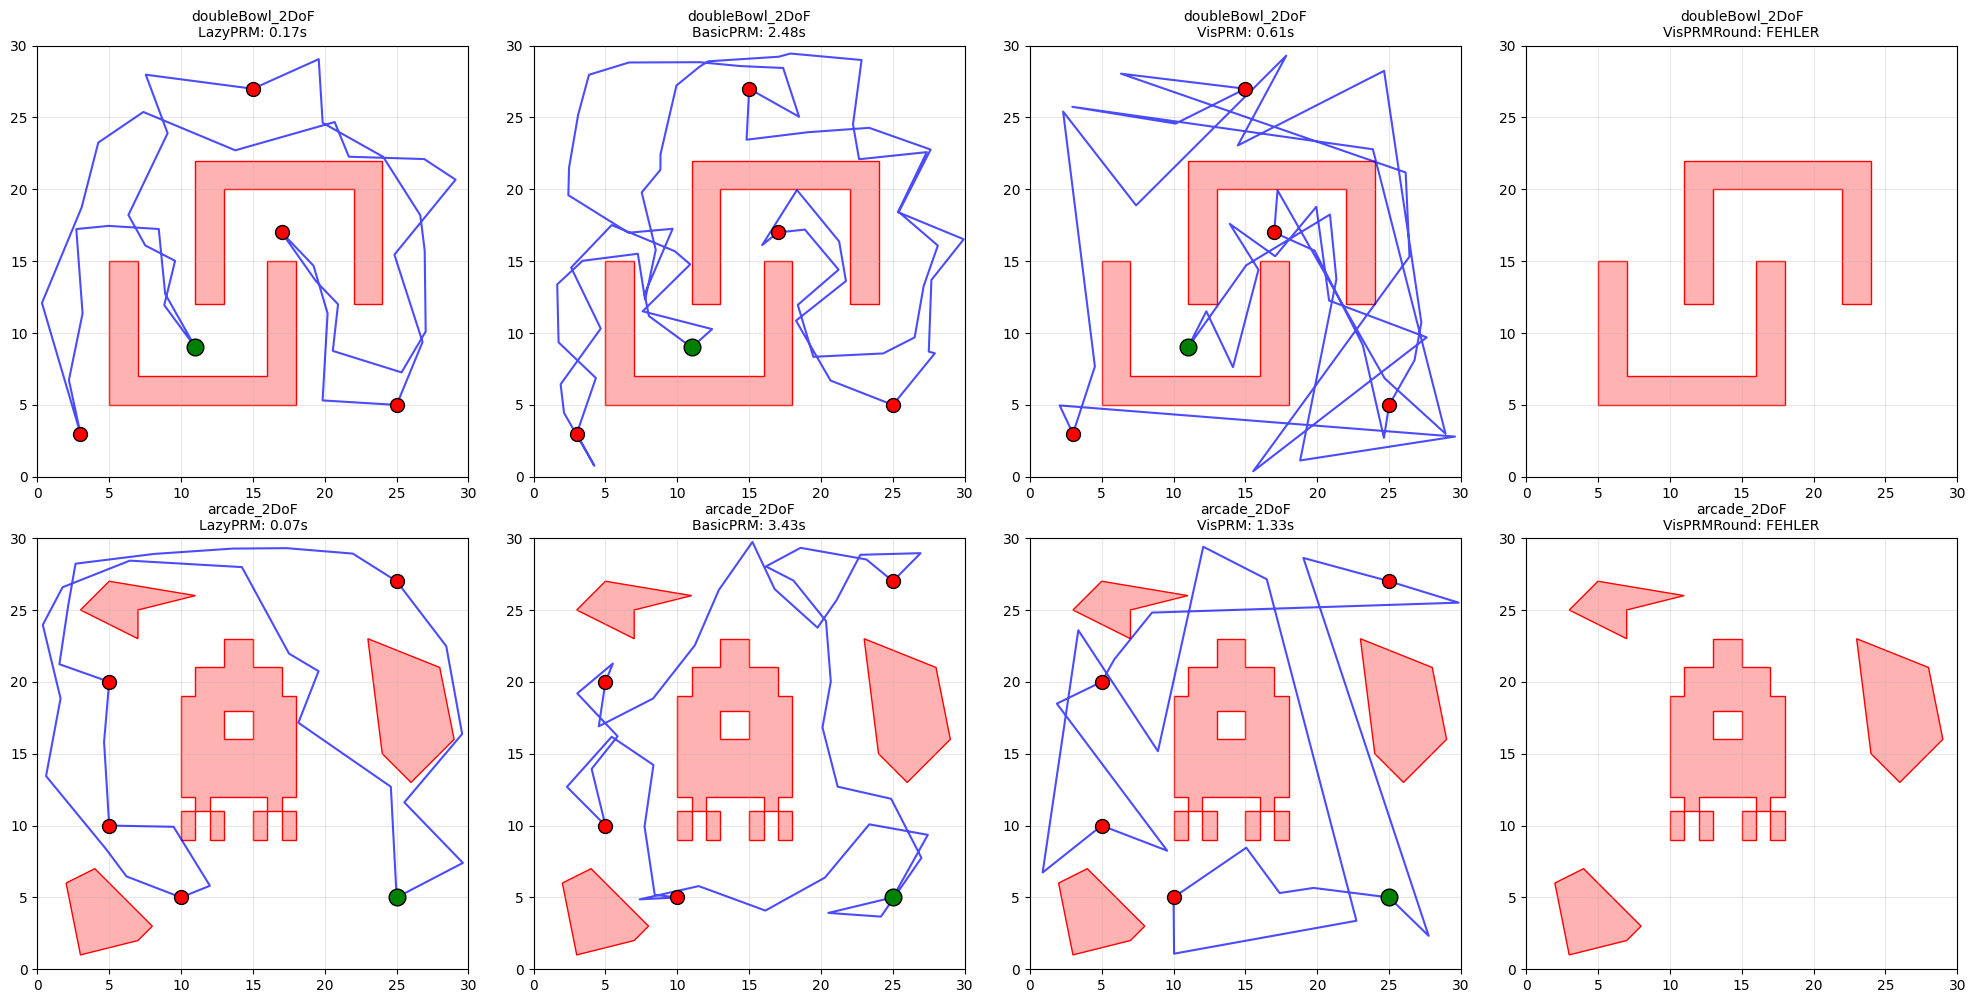

In [5]:
# ============================================================================
# ERGEBNISSE PLOTTEN: Alle Pfade nebeneinander
# ============================================================================
successful_results = [r for r in results if r['success']]

# Anzahl Plots
n_benchmarks = len(benchmarks_2dof)
n_planners = len(planner_names)

fig, axes = plt.subplots(n_benchmarks, n_planners, figsize=(5*n_planners, 5*n_benchmarks))

for bench_idx, bench in enumerate(benchmarks_2dof):
    for plan_idx, planner_name in enumerate(planner_names):
        ax = axes[bench_idx, plan_idx] if n_benchmarks > 1 else axes[plan_idx]

        # Finde das Ergebnis
        result = next((r for r in successful_results
                       if r['benchmark'] == bench.name and r['planner'] == planner_name), None)

        env = bench.collisionChecker
        limits = env.getEnvironmentLimits()
        ax.set_xlim(limits[0])
        ax.set_ylim(limits[1])

        # Hindernisse
        env.drawObstacles(ax)

        if result and result['path']:
            path = result['path']
            # Pfad zeichnen
            x_coords = [p[0] for p in path]
            y_coords = [p[1] for p in path]
            ax.plot(x_coords, y_coords, 'b-', linewidth=1.5, alpha=0.7)

            # Start (grün)
            ax.plot(path[0][0], path[0][1], 'go', markersize=12, markeredgecolor='black')

            # Ziele (rot)
            for goal in bench.goalList:
                ax.plot(goal[0], goal[1], 'ro', markersize=10, markeredgecolor='black')

            title = f"{bench.name}\n{planner_name}: {result['time']:.2f}s"
        else:
            title = f"{bench.name}\n{planner_name}: FEHLER"

        ax.set_title(title, fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')

plt.tight_layout()
plt.show()

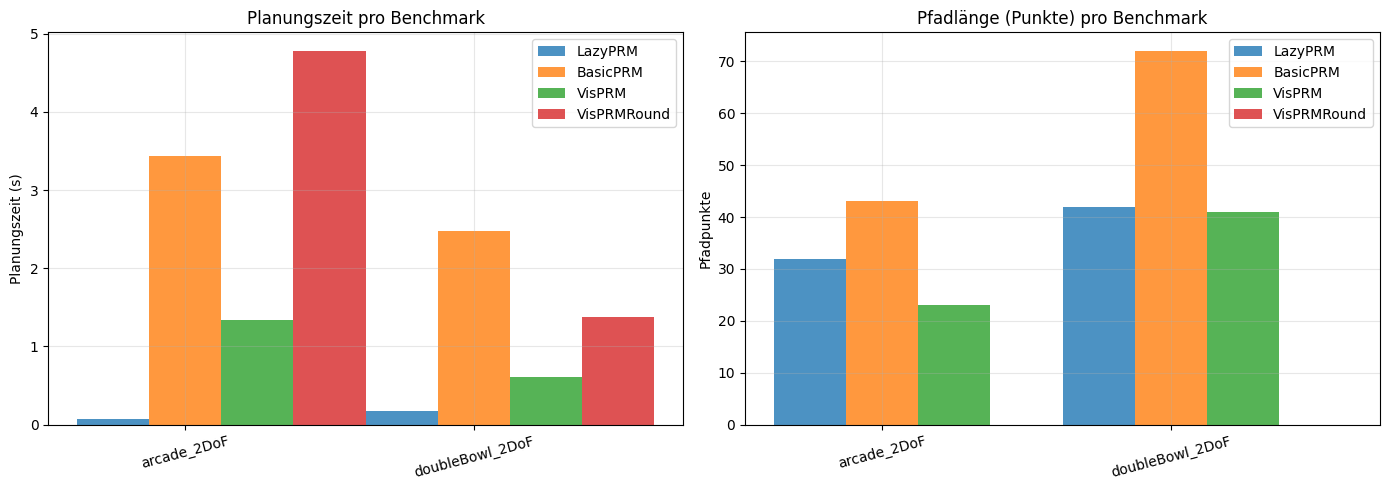


📊 ERGEBNISTABELLE:
------------------------------------------------------------
Benchmark            Planner         Zeit (s)     Punkte    
------------------------------------------------------------
doubleBowl_2DoF      LazyPRM         0.171        42        
doubleBowl_2DoF      BasicPRM        2.480        72        
doubleBowl_2DoF      VisPRM          0.610        41        
doubleBowl_2DoF      VisPRMRound     1.378        0         
arcade_2DoF          LazyPRM         0.070        32        
arcade_2DoF          BasicPRM        3.431        43        
arcade_2DoF          VisPRM          1.332        23        
arcade_2DoF          VisPRMRound     4.780        0         


In [6]:
# ============================================================================
# ERGEBNISSE ALS BALKENDIAGRAMME
# ============================================================================
import numpy as np

successful_results = [r for r in results if r['success']]

if successful_results:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Daten vorbereiten
    benchmarks = list(set(r['benchmark'] for r in successful_results))
    x = np.arange(len(benchmarks))
    width = 0.25

    # Plot 1: Planungszeit
    ax1 = axes[0]
    for i, planner in enumerate(planner_names):
        times = [next((r['time'] for r in successful_results
                      if r['benchmark'] == b and r['planner'] == planner), 0)
                for b in benchmarks]
        ax1.bar(x + i*width, times, width, label=planner, alpha=0.8)

    ax1.set_ylabel('Planungszeit (s)')
    ax1.set_title('Planungszeit pro Benchmark')
    ax1.set_xticks(x + width)
    ax1.set_xticklabels(benchmarks, rotation=15)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Pfadlänge
    ax2 = axes[1]
    for i, planner in enumerate(planner_names):
        points = [next((r['path_points'] for r in successful_results
                       if r['benchmark'] == b and r['planner'] == planner), 0)
                 for b in benchmarks]
        ax2.bar(x + i*width, points, width, label=planner, alpha=0.8)

    ax2.set_ylabel('Pfadpunkte')
    ax2.set_title('Pfadlänge (Punkte) pro Benchmark')
    ax2.set_xticks(x + width)
    ax2.set_xticklabels(benchmarks, rotation=15)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Tabelle
    print("\n📊 ERGEBNISTABELLE:")
    print("-" * 60)
    print(f"{'Benchmark':<20} {'Planner':<15} {'Zeit (s)':<12} {'Punkte':<10}")
    print("-" * 60)
    for r in successful_results:
        print(f"{r['benchmark']:<20} {r['planner']:<15} {r['time']:<12.3f} {r['path_points']:<10}")

In [7]:
# ============================================================================
# PLANER KONFIGURATIONEN FÜR 3-DoF (höhere Werte nötig!)
# ============================================================================
# Basierend auf den funktionierenden Konfigurationen aus Ueb12_robot_3d.ipynb

PLANNERS_3DOF = {
    "BasicPRM": {
        "config": {
            "radius": 15,        # Erhöht von 5 auf 15 (3D Raum braucht größeren Radius)
            "numNodes": 800,     # Erhöht von 300 auf 800
            "useKDTree": True
        },
        "class": BasicPRM
    },
    "LazyPRM": {
        "config": {
            "initialRoadmapSize": 100,   # Erhöht von 40 auf 100
            "updateRoadmapSize": 50,     # Erhöht von 20 auf 50
            "kNearest": 10,              # Erhöht von 5 auf 10
            "maxIterations": 60          # Erhöht von 40 auf 60
        },
        "class": LazyPRM
    },
    "VisPRM": {
        "config": {
            "ntry": 300          # Erhöht von 40 auf 300 (wie in Übungs-Notebooks)
        },
        "class": VisPRM,
    },
    "VisPRMRound": {
        "config": {
            "ntry": 300          # Roundtrip-Variante nutzt eigene TSP-Logik
        },
        "class": VisPRMRound
    },
}

print("3-DoF Planer-Konfigurationen geladen:")
for name, cfg in PLANNERS_3DOF.items():
    print(f"  {name}: {cfg['config']}")

3-DoF Planer-Konfigurationen geladen:
  BasicPRM: {'radius': 15, 'numNodes': 800, 'useKDTree': True}
  LazyPRM: {'initialRoadmapSize': 100, 'updateRoadmapSize': 50, 'kNearest': 10, 'maxIterations': 60}
  VisPRM: {'ntry': 300}
  VisPRMRound: {'ntry': 300}


In [8]:
# ============================================================================
# BENCHMARKING: Alle 3DoF Benchmarks mit allen Planern
# ============================================================================
benchmarks_3dof = getBenchmarks3DoF()
planner_names_3dof = list(PLANNERS_3DOF.keys())

results_3dof = []

print("=" * 70)
print("ROUNDTRIP BENCHMARK - 3DoF Shape-Roboter Szenen")
print("=" * 70)

for bench in benchmarks_3dof:
    print(f"\nBenchmark: {bench.name}")
    print("-" * 50)

    env = bench.collisionChecker
    start_pos = bench.startList[0]
    goal_list = bench.goalList

    for planner_name in planner_names_3dof:
        try:
            # Planer initialisieren
            planner_class = PLANNERS_3DOF[planner_name]["class"]
            planner_config = PLANNERS_3DOF[planner_name]["config"]
            base_planner = planner_class(env)

            # VisPRMRound bringt die Roundtrip-Logik selbst mit, andere nutzen RoundtripPlanner
            start_time = time.time()
            if planner_name == "VisPRMRound":
                path = base_planner.planPath(start_pos, goal_list, planner_config)
            else:
                roundtrip = RoundtripPlanner(env, base_planner)
                path = roundtrip.planPath([start_pos], goal_list, planner_config)
            end_time = time.time()

            planning_time = end_time - start_time
            path_length = len(path)

            # Ergebnis speichern
            results_3dof.append({
                "benchmark": bench.name,
                "planner": planner_name,
                "time": planning_time,
                "path_points": path_length,
                "path": path,
                "success": True
            })

            print(f"  ✅ {planner_name}: {planning_time:.3f}s, {path_length} Punkte")

        except Exception as e:
            results_3dof.append({
                "benchmark": bench.name,
                "planner": planner_name,
                "time": None,
                "path_points": None,
                "path": None,
                "success": False
            })
            print(f" {planner_name}: Fehler - {str(e)[:80]}...")

print("\n" + "=" * 70)

ROUNDTRIP BENCHMARK - 3DoF Shape-Roboter Szenen

Benchmark: spinner_3DoF
--------------------------------------------------
Path Planing gestartet mit BasicPRM

Start: [15, 5, 0]
Goals: 3 Ziele
  - Goal 1: [5, 15, 270]
  - Goal 2: [15, 25, 180]
  - Goal 3: [25, 15, 90]
  TSP-Lösung (Christofides): Approximierte Distanz = 56.57
  Optimierte Reihenfolge: Start → [25, 15, 90] → [15, 25, 180] → [5, 15, 270] → Start

→ Plane Segment 1/4: [15, 5, 0] → [25, 15, 90]
Pfad gefunden: 21 Punkte (im Versuch 1)
Konvertiert zu Koordinaten: 21 Punkte

→ Plane Segment 2/4: [25, 15, 90] → [15, 25, 180]
Pfad gefunden: 27 Punkte (im Versuch 1)
Konvertiert zu Koordinaten: 27 Punkte

→ Plane Segment 3/4: [15, 25, 180] → [5, 15, 270]
Pfad gefunden: 42 Punkte (im Versuch 1)
Konvertiert zu Koordinaten: 42 Punkte

→ Plane Segment 4/4: [5, 15, 270] → [15, 5, 0]
Pfad gefunden: 44 Punkte (im Versuch 1)
Konvertiert zu Koordinaten: 44 Punkte

 Roundtrip erfolgreich geplant!
  - Gesamtpunkte im Pfad: 131
  - Besuchte

KeyboardInterrupt: 

In [ ]:
# ============================================================================
# ERGEBNISSE PLOTTEN: 3-DoF Pfade mit Roboter-Visualisierung
# ============================================================================
successful_results_3dof = [r for r in results_3dof if r['success']]

n_benchmarks_3dof = len(benchmarks_3dof)
n_planners_3dof = len(planner_names_3dof)

if successful_results_3dof:
    fig, axes = plt.subplots(n_benchmarks_3dof, n_planners_3dof,
                             figsize=(5*n_planners_3dof, 5*n_benchmarks_3dof))

    # Falls nur 1 Benchmark, axes anpassen
    if n_benchmarks_3dof == 1:
        axes = [axes]

    for bench_idx, bench in enumerate(benchmarks_3dof):
        for plan_idx, planner_name in enumerate(planner_names_3dof):
            ax = axes[bench_idx][plan_idx] if n_benchmarks_3dof > 1 else axes[plan_idx]

            # Finde das Ergebnis
            result = next((r for r in successful_results_3dof
                           if r['benchmark'] == bench.name and r['planner'] == planner_name), None)

            env = bench.collisionChecker
            limits = env.getEnvironmentLimits()
            ax.set_xlim(limits[0])
            ax.set_ylim(limits[1])

            # Hindernisse
            env.drawObstacles(ax)

            if result and result['path']:
                path = result['path']

                # Pfad zeichnen (x, y Koordinaten)
                x_coords = [p[0] for p in path]
                y_coords = [p[1] for p in path]
                ax.plot(x_coords, y_coords, 'b-', linewidth=2, alpha=0.7)

                # Roboter an einigen Positionen zeichnen (jeden 5. Punkt)
                for i in range(0, len(path), max(1, len(path)//5)):
                    env.drawRobot(ax, path[i])

                # Start (grün) und Ziele (rot) markieren
                ax.scatter(path[0][0], path[0][1], color='green', s=150,
                          zorder=10, marker='o', edgecolors='black', linewidths=2)
                for goal in bench.goalList:
                    ax.scatter(goal[0], goal[1], color='red', s=120,
                              zorder=10, marker='o', edgecolors='black', linewidths=2)

                title = f"{bench.name}\n{planner_name}: {result['time']:.2f}s, {result['path_points']} Punkte"
            else:
                title = f"{bench.name}\n{planner_name}: FEHLER"

            ax.set_title(title, fontsize=10)
            ax.grid(True, alpha=0.3)
            ax.set_aspect('equal')

    plt.tight_layout()
    plt.show()
else:
    print("Keine erfolgreichen 3-DoF Ergebnisse zum Plotten.")

In [ ]:
# ============================================================================
# ERGEBNISSE ALS BALKENDIAGRAMME - 3DoF
# ============================================================================
import numpy as np

successful_results_3dof = [r for r in results_3dof if r['success']]

if successful_results_3dof:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Daten vorbereiten
    benchmarks_3dof_names = list(set(r['benchmark'] for r in successful_results_3dof))
    x = np.arange(len(benchmarks_3dof_names))
    width = 0.25

    # Plot 1: Planungszeit
    ax1 = axes[0]
    for i, planner in enumerate(planner_names_3dof):
        times = [next((r['time'] for r in successful_results_3dof
                      if r['benchmark'] == b and r['planner'] == planner), 0)
                for b in benchmarks_3dof_names]
        ax1.bar(x + i*width, times, width, label=planner, alpha=0.8)

    ax1.set_ylabel('Planungszeit (s)')
    ax1.set_title('3-DoF: Planungszeit pro Benchmark')
    ax1.set_xticks(x + width)
    ax1.set_xticklabels(benchmarks_3dof_names, rotation=15)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Pfadlänge
    ax2 = axes[1]
    for i, planner in enumerate(planner_names_3dof):
        points = [next((r['path_points'] for r in successful_results_3dof
                       if r['benchmark'] == b and r['planner'] == planner), 0)
                 for b in benchmarks_3dof_names]
        ax2.bar(x + i*width, points, width, label=planner, alpha=0.8)

    ax2.set_ylabel('Pfadpunkte')
    ax2.set_title('3-DoF: Pfadlänge (Punkte) pro Benchmark')
    ax2.set_xticks(x + width)
    ax2.set_xticklabels(benchmarks_3dof_names, rotation=15)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Tabelle
    print("\n📊 ERGEBNISTABELLE 3-DoF:")
    print("-" * 60)
    print(f"{'Benchmark':<20} {'Planner':<15} {'Zeit (s)':<12} {'Punkte':<10}")
    print("-" * 60)
    for r in successful_results_3dof:
        print(f"{r['benchmark']:<20} {r['planner']:<15} {r['time']:<12.3f} {r['path_points']:<10}")
else:
    print("Keine erfolgreichen 3-DoF Ergebnisse.")

## Animationen der Pfade 


In [ ]:
# ============================================================================
# MASSEN-ANIMATION: Alle erfolgreichen Pfade animieren
# ============================================================================
import os

# Ordner für Animationen erstellen
output_dir = "animations"
os.makedirs(output_dir, exist_ok=True)

print(f"Starte Generierung der Animationen in '{output_dir}'...")

# Wähle hier, welche Ergebnisse du animieren willst (2DoF oder 3DoF)
# Zum Beispiel beide Listen zusammenführen:
all_results = results + results_3dof
all_benchmarks = benchmarks_2dof + benchmarks_3dof

for res in all_results:
    # Nur erfolgreiche Pfade animieren
    if not res.get('success') or not res.get('path'):
        continue

    # Benchmark-Objekt wiederfinden
    bench = next((b for b in all_benchmarks if b.name == res['benchmark']), None)
    if bench is None:
        continue

    # Prüfen ob 3-DoF (für angepasste Schrittweite)
    is_3dof = hasattr(bench.collisionChecker, 'drawRobot')

    # Dateiname generieren
    filename = f"{output_dir}/{res['benchmark']}_{res['planner']}.html"

    # Animator initialisieren
    animator = PathAnimator(bench, res['path'], res['planner'], res['time'])

    print(f"  - Animiere {res['benchmark']} mit {res['planner']}...", end="")

    # Animation erstellen und speichern (show_inline=False spart Speicher im Notebook)
    animator.animate(
        step_size=2.0 if is_3dof else 2.0,  # Größere Schritte für performance
        interval_ms=50,                     # Schnellerer Ablauf
        repeat=1,
        max_frames=250,                     # Limit um Dateigröße klein zu halten
        save_html_path=filename,            # Speichern
        show_inline=True                   # ob abspeichern oder in notebook anzeigen.
    )

print(f"\n Alle Animationen wurden im Ordner '{output_dir}/' gespeichert.")